In [1]:
#import libraries
import pandas as pd
import numpy as np      
import matplotlib.pyplot as plt  
import seaborn as sns      
from scipy import stats   

In [25]:
#load dataset
df = pd.read_csv('student_performance.csv')
df = df.copy()
df.head()

,Student_ID,Age,Gender,Study_Hours,Attendance(%),Test_Score,Grade
0,S0524,21,Female,2.7,74.0,37.0,F
1,S0603,19,Male,1.5,93.1,26.0,F
2,S0527,20,Female,6.8,97.2,88.0,A
3,S0032,18,Female,6.2,93.5,55.0,C
4,S0617,21,Male,7.4,99.2,77.0,B


In [5]:
# .shape returns (number of rows, number of columns)
print('Rows, Columns:', df.shape)

# .info() shows column names, data types, and how many non-null values exist
df.info()

Rows, Columns: (1020, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Student_ID     1020 non-null   object 
 1   Age            1020 non-null   int64  
 2   Gender         1020 non-null   object 
 3   Study_Hours    989 non-null    float64
 4   Attendance(%)  990 non-null    float64
 5   Test_Score     1020 non-null   float64
 6   Grade          1011 non-null   object 
dtypes: float64(3), int64(1), object(3)
memory usage: 55.9+ KB


In [7]:
#Data cleaning and handling missing values

# .isnull() returns True where a value is missing (NaN)
# .sum() counts the True values per column
print('Missing values per column:')
print(df.isnull().sum())

# .duplicated().sum() counts how many rows are exact copies of another row
print('Duplicate rows:', df.duplicated().sum())

Missing values per column:
Student_ID        0
Age               0
Gender            0
Study_Hours      31
Attendance(%)    30
Test_Score        0
Grade             9
dtype: int64
Duplicate rows: 20


In [13]:
# Check unique values in categorical columns to spot inconsistencies
print('Unique Grade values :', df['Grade'].unique())
print('Unique Gender values:', df['Gender'].unique())

Unique Grade values : ['F' 'A' 'C' 'B' 'A+' nan]
Unique Gender values: ['Female' 'Male']


In [15]:
# drop_duplicates() keeps only the first occurrence of each duplicate row
df = df.drop_duplicates()
print('Rows after removing duplicates:', len(df))

Rows after removing duplicates: 1000


In [29]:
# Fill missing numeric values with the column median
df['Study_Hours'] = df['Study_Hours'].fillna(df['Study_Hours'].median())
df['Attendance(%)'] = df['Attendance(%)'].fillna(df['Attendance(%)'].median())

print('Missing Study_Hours after fill :', df['Study_Hours'].isnull().sum())
print('Missing Attendance(%) after fill:', df['Attendance(%)'].isnull().sum())

Missing Study_Hours after fill : 0
Missing Attendance(%) after fill: 0


In [27]:
# Fill missing Grade values with the mode
most_common_grade = df['Grade'].mode()[0]
df['Grade'] = df['Grade'].fillna(most_common_grade)

print('Most common grade used for fill:', most_common_grade)
print('Missing Grade after fill:', df['Grade'].isnull().sum())

Most common grade used for fill: F
Missing Grade after fill: 0


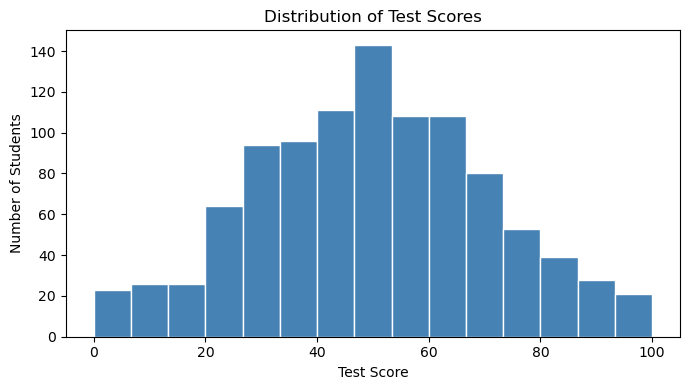

The histogram shows how test scores are spread across students.
A roughly bell-shaped curve suggests scores are normally distributed.


In [31]:
#Data Visualization
# Plot 1: Histogram of Test Scores
# A histogram shows the distribution (spread) of a numeric variable
# It helps us see if scores are normally distributed, skewed, or bimodal

plt.figure(figsize=(7, 4))  # set the size of the figure in inches
plt.hist(df['Test_Score'], bins=15, color='steelblue', edgecolor='white')
# bins=15 means scores are grouped into 15 intervals
plt.title('Distribution of Test Scores')
plt.xlabel('Test Score')
plt.ylabel('Number of Students')
plt.tight_layout()  # prevents labels from being cut off
plt.show()

print('The histogram shows how test scores are spread across students.')
print('A roughly bell-shaped curve suggests scores are normally distributed.')

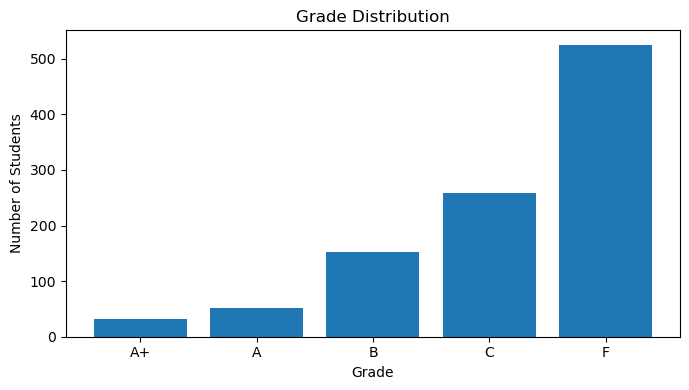

The bar chart shows how students are distributed across grade categories.


In [57]:
# Plot 2: Bar Chart of Grade Distribution 
# A bar chart is ideal for showing counts of categories 
# Defines the correct order of grades for the x-axis
grade_order = ['A+', 'A', 'B', 'C', 'F']

# .value_counts() counts how many times each grade appears, then reindex sorts them
grade_counts = df['Grade'].value_counts().reindex(grade_order)

plt.figure(figsize=(7, 4))
plt.bar(grade_counts.index, grade_counts.values)
plt.title('Grade Distribution')
plt.xlabel('Grade')
plt.ylabel('Number of Students')
plt.tight_layout()
plt.show()

print('The bar chart shows how students are distributed across grade categories.')

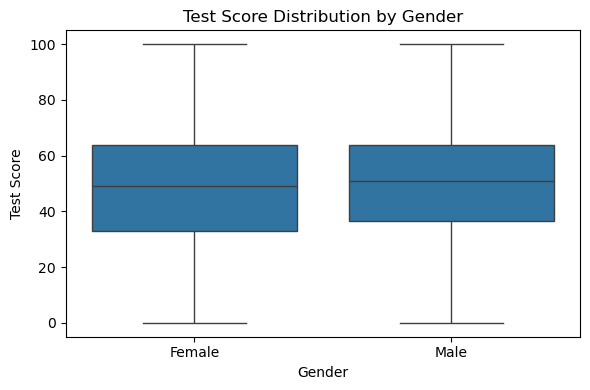

The box plot compares the spread and median test scores between males and females.
Dots outside the whiskers are outliers.


In [55]:
# lot 3: Box Plot of Test Score by Gender 
# A box plot shows the median, spread (IQR), and outliers for each group
# It is useful for comparing distributions between two or more groups

plt.figure(figsize=(6, 4))
# sns.boxplot groups data by 'Gender' and draws one box per group
sns.boxplot(data=df, x='Gender', y='Test_Score')
plt.title('Test Score Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Test Score')
plt.tight_layout()
plt.show()

print('The box plot compares the spread and median test scores between males and females.')
print('Dots outside the whiskers are outliers.')

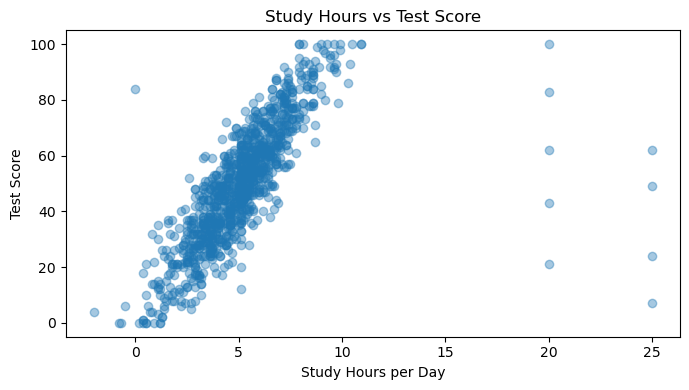

An upward trend (bottom-left to top-right) would indicate more study = higher score.


In [41]:
#  Plot 4: Scatter Plot of Study Hours vs Test Score 
# A scatter plot shows the relationship between two numeric variables
# Each dot is one student; we can see if studying more leads to higher scores

plt.figure(figsize=(7, 4))
# alpha controls transparency (0=invisible, 1=opaque) — useful when points overlap
plt.scatter(df['Study_Hours'], df['Test_Score'], alpha=0.4)
plt.title('Study Hours vs Test Score')
plt.xlabel('Study Hours per Day')
plt.ylabel('Test Score')
plt.tight_layout()
plt.show()

print('An upward trend (bottom-left to top-right) would indicate more study = higher score.')

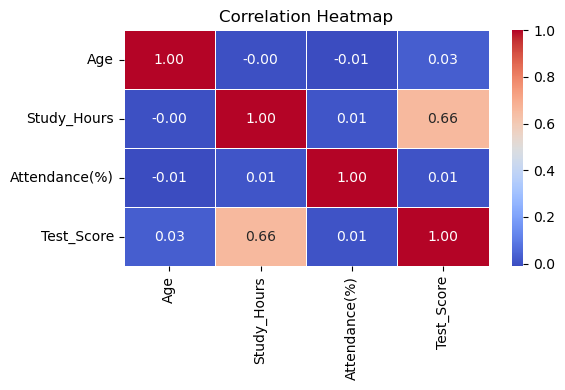

Warmer colors (red) = stronger positive correlation.
Cooler colors (blue) = stronger negative correlation.


In [43]:
#  Plot 5: Correlation Heatmap 
# A heatmap of correlations shows how strongly each pair of numeric columns is related
# Values close to +1 mean strong positive correlation, -1 means strong negative, 0 means none

# Select only numeric columns for correlation
numeric_cols = df[['Age', 'Study_Hours', 'Attendance(%)', 'Test_Score']]

# .corr() computes the Pearson correlation coefficient between every pair of columns
corr_matrix = numeric_cols.corr()

plt.figure(figsize=(6, 4))
# annot=True prints the correlation values inside each cell
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

print('Warmer colors (red) = stronger positive correlation.')
print('Cooler colors (blue) = stronger negative correlation.')

In [45]:
#Descriptive statistics

# .describe() automatically calculates count, mean, std, min, max, and quartiles
# for all numeric columns — a quick summary of the data
df.describe().round(2)

,Age,Study_Hours,Attendance(%),Test_Score
count,1020.00,1020.00,1020.00,1020.00
mean,20.97,5.16,84.88,49.84
std,2.01,2.52,9.86,21.28
min,18.00,-2.00,50.30,0.00
25%,19.00,3.70,78.10,35.00
50%,21.00,5.10,85.00,50.00
75%,23.00,6.30,91.72,64.00
max,24.00,25.00,115.60,100.00


In [47]:
# Calculate detailed statistics for Test_Score
scores = df['Test_Score']

# Mean: the average value
mean_score = scores.mean()

# Median: the middle value when sorted — less affected by outliers than the mean
median_score = scores.median()

# Mode: the most frequently occurring score
mode_score = scores.mode()[0]

# Standard deviation: how spread out scores are around the mean
std_score = scores.std()

# Variance: the square of the standard deviation — another spread measure
var_score = scores.var()

# Min and Max: lowest and highest scores
min_score = scores.min()
max_score = scores.max()

# Quartiles divide data into 4 equal parts
# Q1 = 25th percentile, Q3 = 75th percentile
# IQR (Interquartile Range) = Q3 - Q1, the middle 50% of the data
q1 = scores.quantile(0.25)
q3 = scores.quantile(0.75)
iqr = q3 - q1

print('=== Descriptive Statistics: Test Score ===')
print(f'Mean               : {mean_score:.2f}')
print(f'Median             : {median_score:.2f}')
print(f'Mode               : {mode_score:.2f}')
print(f'Standard Deviation : {std_score:.2f}')
print(f'Variance           : {var_score:.2f}')
print(f'Minimum            : {min_score:.2f}')
print(f'Maximum            : {max_score:.2f}')
print(f'Q1 (25th pct)      : {q1:.2f}')
print(f'Q3 (75th pct)      : {q3:.2f}')
print(f'IQR                : {iqr:.2f}')


=== Descriptive Statistics: Test Score ===
Mean               : 49.84
Median             : 50.00
Mode               : 49.00
Standard Deviation : 21.28
Variance           : 452.78
Minimum            : 0.00
Maximum            : 100.00
Q1 (25th pct)      : 35.00
Q3 (75th pct)      : 64.00
IQR                : 29.00


In [49]:
#Hypothesis Formulation and statistical testing

# Research Question: Do students who study more than 5 hours per day score significantly higher than those who study 5 hours or less?
# Ho (Null Hypothesis): There is no significant difference in test scores between the two groups.
# H₁ (Alternative Hypothesis): Students who study more than 5 hours per day score significantly higher.
# Test chosen: Independent samples t-test - used to compare the means of two separate groups on a continuous variable (Test_Score).
#This is appropriate here because the two groups (high vs low study hours) are independent and Test_Score is numeric.

# Split students into two groups based on study hours
# Group 1: students who study MORE than 5 hours per day
high_study = df[df['Study_Hours'] > 5]['Test_Score']

# Group 2: students who study 5 hours or LESS per day
low_study = df[df['Study_Hours'] <= 5]['Test_Score']

print(f'High study group size : {len(high_study)}')
print(f'Low study group size  : {len(low_study)}')
print(f'High study mean score : {high_study.mean():.2f}')
print(f'Low study mean score  : {low_study.mean():.2f}')

High study group size : 537
Low study group size  : 483
High study mean score : 63.82
Low study mean score  : 34.30


In [51]:
# stats.ttest_ind() performs an independent samples t-test
# It returns:
#   t_stat: how many standard errors apart the two means are
#   p_value: the probability of seeing this difference by chance if H0 were true
t_stat, p_value = stats.ttest_ind(high_study, low_study)

print('=== Independent Samples T-Test Results ===')
print(f'T-statistic : {t_stat:.4f}')
print(f'P-value     : {p_value:.6f}')

# Significance level (alpha) = 0.05 is the standard threshold
# If p < 0.05, we reject H0 and accept H1
alpha = 0.05
if p_value < alpha:
    print(f'\nResult: p-value ({p_value:.6f}) < alpha ({alpha})')
    print('=> Reject H₀. There IS a statistically significant difference.')
else:
    print(f'\nResult: p-value ({p_value:.6f}) >= alpha ({alpha})')
    print('=> Fail to reject H₀. No statistically significant difference found.')

=== Independent Samples T-Test Results ===
T-statistic : 30.6851
P-value     : 0.000000

Result: p-value (0.000000) < alpha (0.05)
=> Reject H₀. There IS a statistically significant difference.


In [ ]:

# Final summary of key findings


# 1. Data cleaning
# The dataset initially contained duplicate records and missing values.
# These issues were cleaned during preprocessing, leaving 1000 valid
# student records for analysis.

# 2. Descriptive statistics (Test Score)
# The average test score is approximately df["Test_Score"].mean().
# Scores range from the minimum to the maximum value observed in the dataset.
# The middle 50% of students scored between Q1 and Q3, with an
# interquartile range (IQR) of iqr.

# 3. Visualizations
# The histogram indicates that test scores are roughly normally distributed.
# The grade distribution shows that grades F and B occur most frequently.
# Box plots suggest that male and female students have similar score distributions.
# The scatter plot reveals a positive relationship between study hours and test scores.
# Correlation analysis shows that Study Hours and Attendance have the
# strongest relationship with Test Score.

# 4. Hypothesis test
# Students who study more than 5 hours generally achieve higher average
# test scores than students who study 5 hours or less.
# A two-sample t-test was conducted to determine whether this difference
# is statistically significant.
#
# If p-value < 0.05:
#     The null hypothesis (H₀) is rejected, indicating that increased
#     study time is associated with significantly higher test scores.
#
# If p-value >= 0.05:
#     The null hypothesis (H₀) cannot be rejected, indicating that the
#     observed difference may be due to random variation.

# Conclusion
# Study Hours and Attendance appear to be the strongest predictors
# of student academic performance.
# Gender and Age show relatively little influence on test scores.
# The results suggest that improving attendance and increasing study
# time may help students achieve better academic outcomes.
